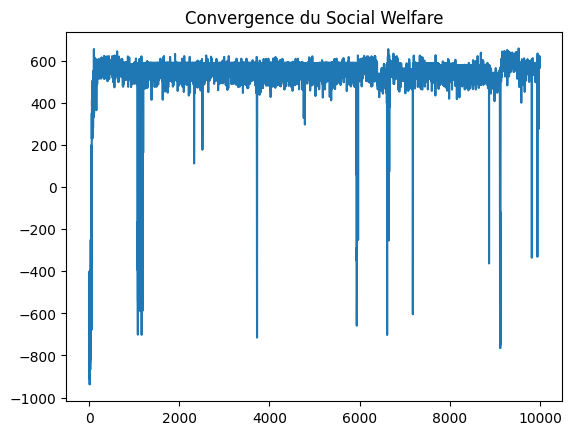

In [24]:
import matplotlib.pyplot as plt
from env import EcoSystem
from agent import GovernmentAgent

# Initialisation
env = EcoSystem()
agent =GovernmentAgent()

# Boucle d'entraînement
rewards, pollutions = [], []

for ep in range(10000):
    state = env.reset()
    ep_reward = 0
    for t in range(50):
        a_idx = agent.get_action(state)
        a_type, a_val = agent.actions[a_idx]
        next_state, r, _ = env.step(a_type, a_val)
        agent.learn(state, a_idx, r, next_state)
        state = next_state
        ep_reward += r
    
    rewards.append(ep_reward)
    pollutions.append(state)

# Plotting
plt.plot(rewards)
plt.title("Convergence du Social Welfare")
plt.show()

    Pollution  Type (0=Tax, 1=Quota)  Valeur
0           0                      1       6
1           5                      0       3
2          10                      1      10
3          15                      1       6
4          20                      1       4
5          25                      1      10
6          30                      1       4
7          35                      0       3
8          40                      0       1
9          45                      1       8
10         50                      0       0
11         55                      1      10
12         60                      1       6
13         65                      0       1
14         70                      1      10
15         75                      1       6
16         80                      1       4
17         85                      1       4
18         90                      1       2
19         95                      1       2


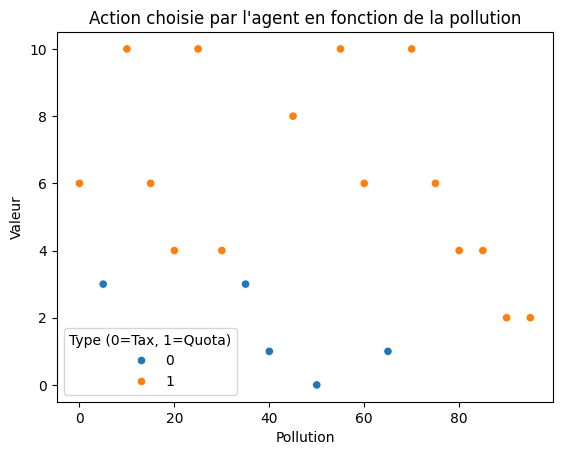

In [25]:
import pandas as pd
import seaborn as sns
import numpy as np

# On extrait la meilleure action pour chaque niveau de pollution (état)
policy_data = []
for s in range(20): # Nos 20 paliers de pollution
    if s in agent.q_table:
        best_action_idx = np.argmax(agent.q_table[s])
        a_type, a_val = agent.actions[best_action_idx]
        policy_data.append([s*5, a_type, a_val])

df_policy = pd.DataFrame(policy_data, columns=['Pollution', 'Type (0=Tax, 1=Quota)', 'Valeur'])
print(df_policy)

# Visualisation rapide
sns.scatterplot(data=df_policy, x='Pollution', y='Valeur', hue='Type (0=Tax, 1=Quota)')
plt.title("Action choisie par l'agent en fonction de la pollution")
plt.show()

In [26]:
# Initialisation
from agent import FirmAgent
gov = GovernmentAgent()
firm = FirmAgent()
env = EcoSystem(n_firms=1) # On commence avec 1 seule firme

for ep in range(10000):
    pol_state = env.reset()
    
    for t in range(50):
        # 1. Le gouvernement choisit (Type, Valeur)
        gov_idx = gov.get_action(pol_state)
        a_type, a_val = gov.actions[gov_idx]
        
        # 2. La firme observe la politique et choisit q
        firm_state = firm.get_state_key(a_type, a_val)
        q_idx = firm.get_action(firm_state)
        q_val = firm.actions[q_idx]
        
        # 3. L'environnement s'exécute
        next_pol, reward_gov, reward_firm = env.step_with_firm(a_type, a_val, q_val)
        
        # 4. Apprentissage double
        next_firm_state = firm.get_state_key(a_type, a_val) # simplification
        firm.learn(firm_state, q_idx, reward_firm, next_firm_state)
        gov.learn(pol_state, gov_idx, reward_gov, next_pol)
        
        pol_state = next_pol

In [27]:
# Initialisation des agents et de l'environnement
env = EcoSystem(n_firms=1)
gov = GovernmentAgent()
firm = FirmAgent()

# INITIALISATION DE LA VARIABLE HISTORY (C'est ce qui manquait !)
history = {
    "reward_gov": [],
    "reward_firm": [],
    "pollution": []
}

for ep in range(10000):
    pol_state = env.reset()
    ep_reward_gov = 0
    ep_reward_firm = 0
    
    for t in range(50):
        # 1. Décision Gouvernement
        gov_idx = gov.get_action(pol_state)
        a_type, a_val = gov.actions[gov_idx]
        
        # 2. Décision Firme
        firm_state = firm.get_state_key(a_type, a_val)
        q_idx = firm.get_action(firm_state)
        q_val = firm.actions[q_idx]
        
        # 3. Step environnement
        next_pol, r_gov, r_firm = env.step_with_firm(a_type, a_val, q_val)
        
        # 4. Apprentissage
        firm.learn(firm_state, q_idx, r_firm, firm.get_state_key(a_type, a_val))
        gov.learn(pol_state, gov_idx, r_gov, next_pol)
        
        # Mise à jour de l'état et cumul des rewards de l'épisode
        pol_state = next_pol
        ep_reward_gov += r_gov
        ep_reward_firm += r_firm

    # ON REMPLIT LE DICTIONNAIRE À CHAQUE FIN D'ÉPISODE
    history["reward_gov"].append(ep_reward_gov / 50) # Moyenne par pas de temps
    history["reward_firm"].append(ep_reward_firm / 50)
    history["pollution"].append(pol_state)

    if ep % 500 == 0:
        print(f"Épisode {ep} terminé")

Épisode 0 terminé
Épisode 500 terminé
Épisode 1000 terminé
Épisode 1500 terminé
Épisode 2000 terminé
Épisode 2500 terminé
Épisode 3000 terminé
Épisode 3500 terminé
Épisode 4000 terminé
Épisode 4500 terminé
Épisode 5000 terminé
Épisode 5500 terminé
Épisode 6000 terminé
Épisode 6500 terminé
Épisode 7000 terminé
Épisode 7500 terminé
Épisode 8000 terminé
Épisode 8500 terminé
Épisode 9000 terminé
Épisode 9500 terminé


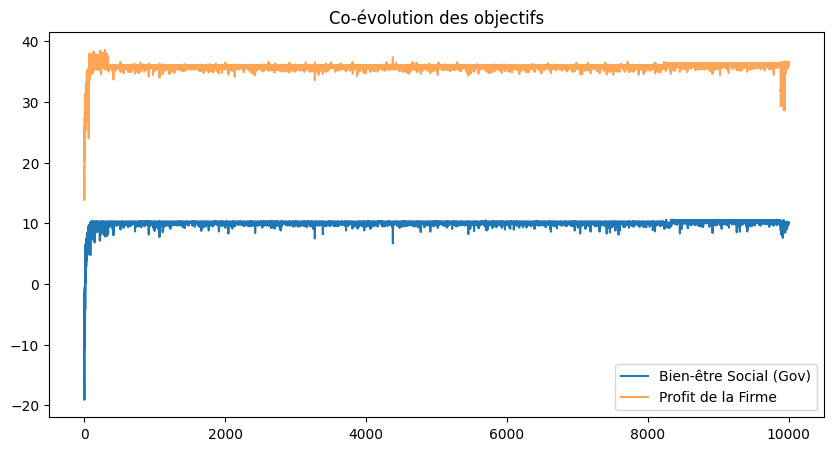

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(history["reward_gov"], label="Bien-être Social (Gov)")
plt.plot(history["reward_firm"], label="Profit de la Firme", alpha=0.7)
plt.legend()
plt.title("Co-évolution des objectifs")
plt.show()

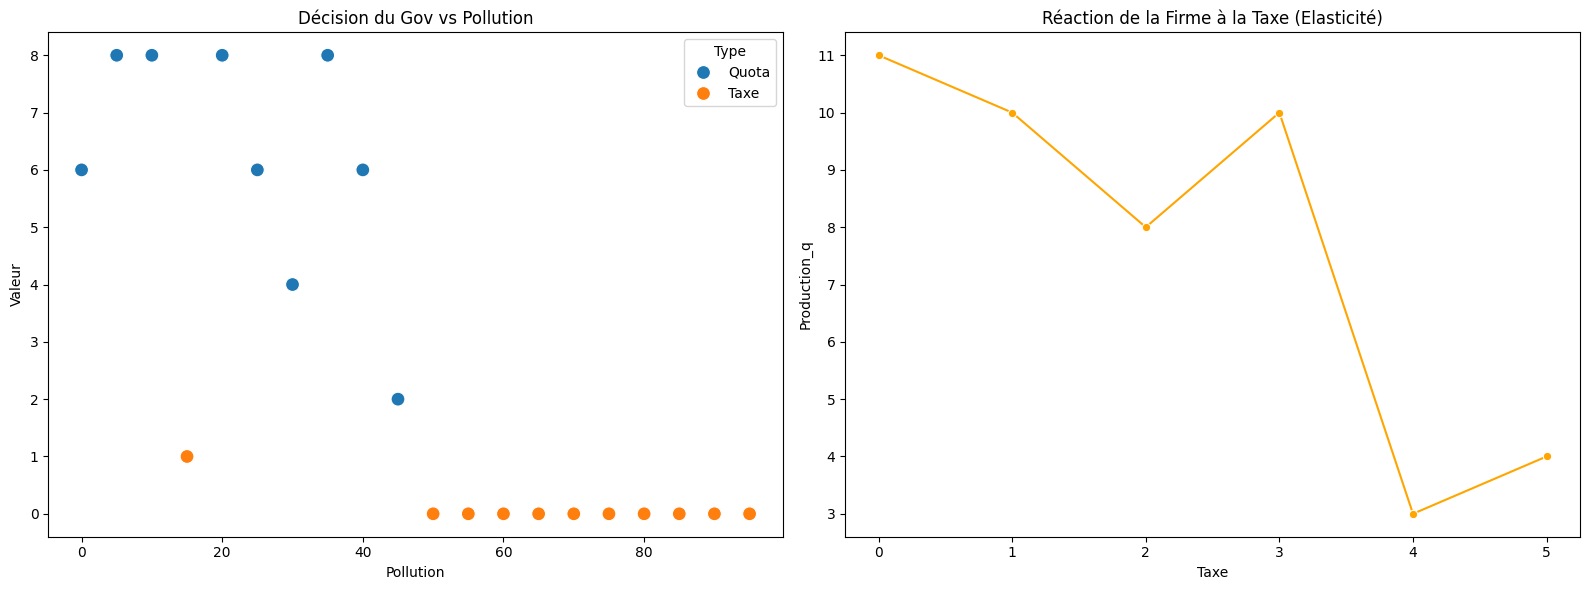

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_final_policies(gov_agent, firm_agent):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 1. Politique du Gouvernement ---
    gov_policy = []
    # On teste pour 20 niveaux de pollution
    for p in range(20):
        state = p * 5 
        a_idx = gov_agent.get_action(state)
        a_type, a_val = gov_agent.actions[a_idx]
        gov_policy.append({"Pollution": state, "Valeur": a_val, "Type": "Taxe" if a_type == 0 else "Quota"})
    
    df_gov = pd.DataFrame(gov_policy)
    sns.scatterplot(data=df_gov, x="Pollution", y="Valeur", hue="Type", ax=ax1, s=100)
    ax1.set_title("Décision du Gov vs Pollution")

    # --- 2. Réaction de la Firme ---
    firm_policy = []
    # On teste la réaction de la firme à différentes taxes (Type 0)
    for t in np.linspace(0, 5, 11):
        state_key = (0, round(t, 1))
        if state_key in firm_agent.q_table:
            q_idx = np.argmax(firm_agent.q_table[state_key])
            q_val = firm_agent.actions[q_idx]
            firm_policy.append({"Taxe": t, "Production_q": q_val})
    
    df_firm = pd.DataFrame(firm_policy)
    if not df_firm.empty:
        sns.lineplot(data=df_firm, x="Taxe", y="Production_q", marker="o", ax=ax2, color="orange")
        ax2.set_title("Réaction de la Firme à la Taxe (Elasticité)")
    
    plt.tight_layout()
    plt.show()

# Appeler la fonction
plot_final_policies(gov, firm)

In [30]:
def plot_action_scatter(history):
    # Note : Il faut avoir enregistré a_val et q_val dans ton dictionnaire history
    # pendant l'entraînement pour que cela fonctionne.
    plt.figure(figsize=(8, 6))
    plt.scatter(history["last_taxes"], history["last_productions"], alpha=0.5)
    plt.xlabel("Taxe imposée par le Gouvernement")
    plt.ylabel("Production choisie par la Firme")
    plt.title("Nuage de points : Interaction Taxe vs Production")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

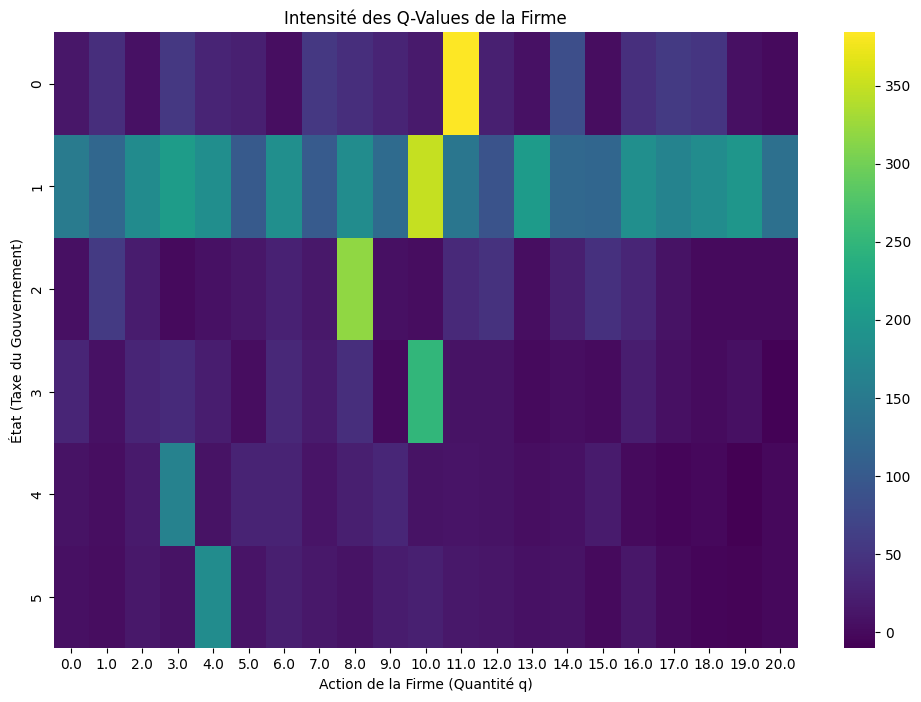

In [31]:
def plot_q_table_heatmap(agent_firm):
    # Transformer la Q-table en matrice
    states = sorted(list(agent_firm.q_table.keys()))
    # On ne filtre que les taxes (type 0) pour la clarté
    tax_states = [s for s in states if s[0] == 0]
    
    if not tax_states: return
    
    q_matrix = np.array([agent_firm.q_table[s] for s in tax_states])
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(q_matrix, xticklabels=np.round(agent_firm.actions, 1), 
                yticklabels=[s[1] for s in tax_states], cmap="viridis")
    plt.xlabel("Action de la Firme (Quantité q)")
    plt.ylabel("État (Taxe du Gouvernement)")
    plt.title("Intensité des Q-Values de la Firme")
    plt.show()

plot_q_table_heatmap(firm)

In [32]:
# Initialisation
env = EcoSystem(n_firms=5)
gov = GovernmentAgent()
# On crée 5 firmes différentes
firms = [FirmAgent(lr=0.1, epsilon=1.0) for _ in range(5)]

history = {"reward_gov": [], "pollution": [], "profits_firms": [[] for _ in range(5)]}

for ep in range(4000): # On augmente un peu car il y a plus d'agents qui apprennent
    pol_state = env.reset()
    ep_reward_gov = 0
    
    for t in range(50):
        # 1. Le gouvernement choisit sa politique
        gov_idx = gov.get_action(pol_state)
        a_type, a_val = gov.actions[gov_idx]
        
        # 2. Chaque firme observe la politique et choisit sa production
        q_indices = []
        q_values = []
        firm_state_key = firms[0].get_state_key(a_type, a_val)
        
        for f in firms:
            idx = f.get_action(firm_state_key)
            q_indices.append(idx)
            q_values.append(f.actions[idx])
        
        # 3. L'environnement calcule les résultats
        next_pol, r_gov, r_firms = env.step_multi_firms(a_type, a_val, q_values)
        
        # 4. Apprentissage
        # Le gouvernement apprend du bien-être social
        gov.learn(pol_state, gov_idx, r_gov, next_pol)
        
        # Chaque firme apprend de son PROPRE profit r_firms[i]
        for i in range(5):
            firms[i].learn(firm_state_key, q_indices[i], r_firms[i], firm_state_key)
            
        pol_state = next_pol
        ep_reward_gov += r_gov

    history["reward_gov"].append(ep_reward_gov / 50)
    history["pollution"].append(pol_state)

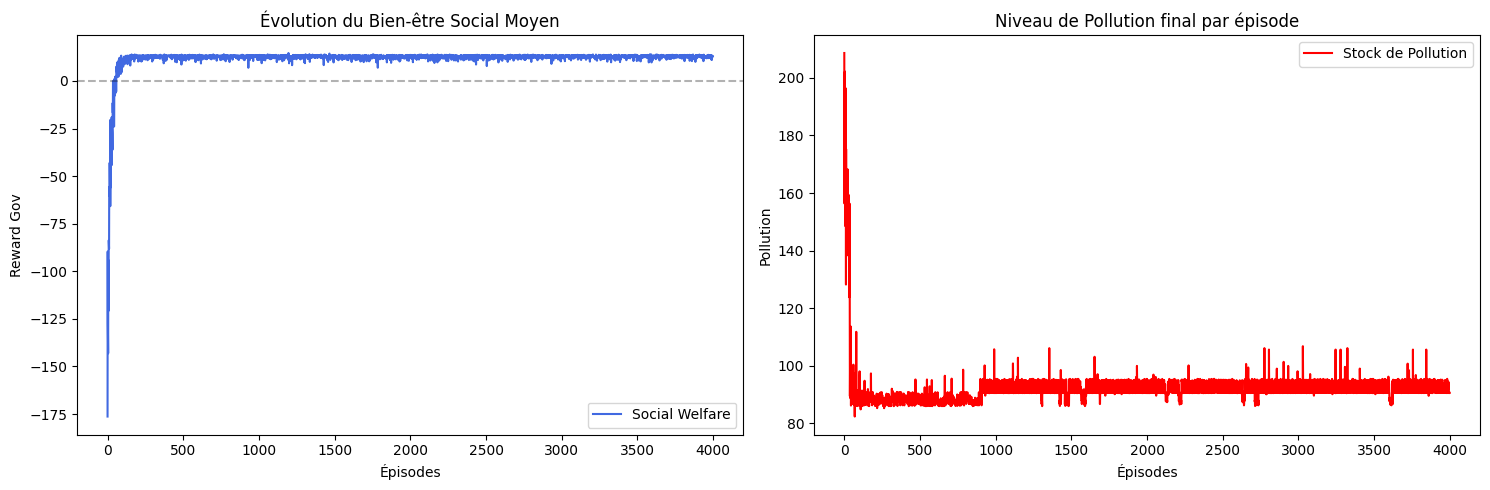

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot du Bien-être Social
plt.subplot(1, 2, 1)
plt.plot(history["reward_gov"], color='royalblue', label="Social Welfare")
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Évolution du Bien-être Social Moyen")
plt.xlabel("Épisodes")
plt.ylabel("Reward Gov")
plt.legend()

# Plot de la Pollution
plt.subplot(1, 2, 2)
plt.plot(history["pollution"], color='red', label="Stock de Pollution")
plt.title("Niveau de Pollution final par épisode")
plt.xlabel("Épisodes")
plt.ylabel("Pollution")
plt.legend()

plt.tight_layout()
plt.show()

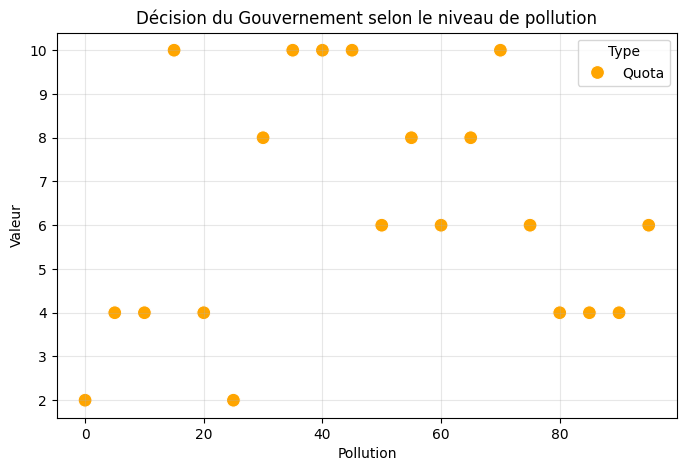

In [34]:
import pandas as pd
import seaborn as sns

gov_policy = []
for p in range(20):
    state = p * 5 
    a_idx = gov.get_action(state)
    a_type, a_val = gov.actions[a_idx]
    gov_policy.append({
        "Pollution": state, 
        "Valeur": a_val, 
        "Type": "Taxe" if a_type == 0 else "Quota"
    })

df_gov = pd.DataFrame(gov_policy)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_gov, x="Pollution", y="Valeur", hue="Type", s=100, palette={"Taxe": "blue", "Quota": "orange"})
plt.title("Décision du Gouvernement selon le niveau de pollution")
plt.grid(True, alpha=0.3)
plt.show()

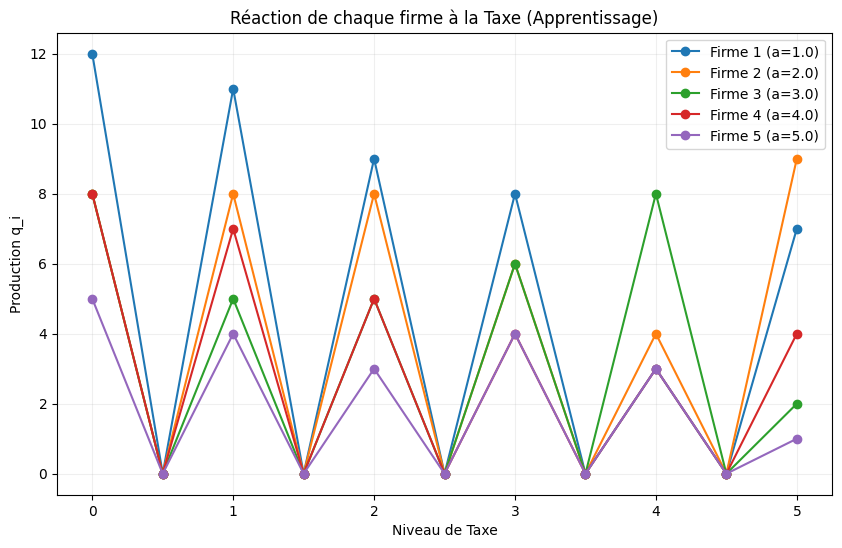

In [35]:
plt.figure(figsize=(10, 6))
taxes = np.linspace(0, 5, 11)

for i in range(5):
    prods = []
    for t in taxes:
        s_key = firms[i].get_state_key(0, round(t, 1))
        if s_key in firms[i].q_table:
            idx = np.argmax(firms[i].q_table[s_key])
            prods.append(firms[i].actions[idx])
        else:
            prods.append(0)
    plt.plot(taxes, prods, label=f"Firme {i+1} (a={env.a_i[i]:.1f})", marker='o')

plt.title("Réaction de chaque firme à la Taxe (Apprentissage)")
plt.xlabel("Niveau de Taxe")
plt.ylabel("Production q_i")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

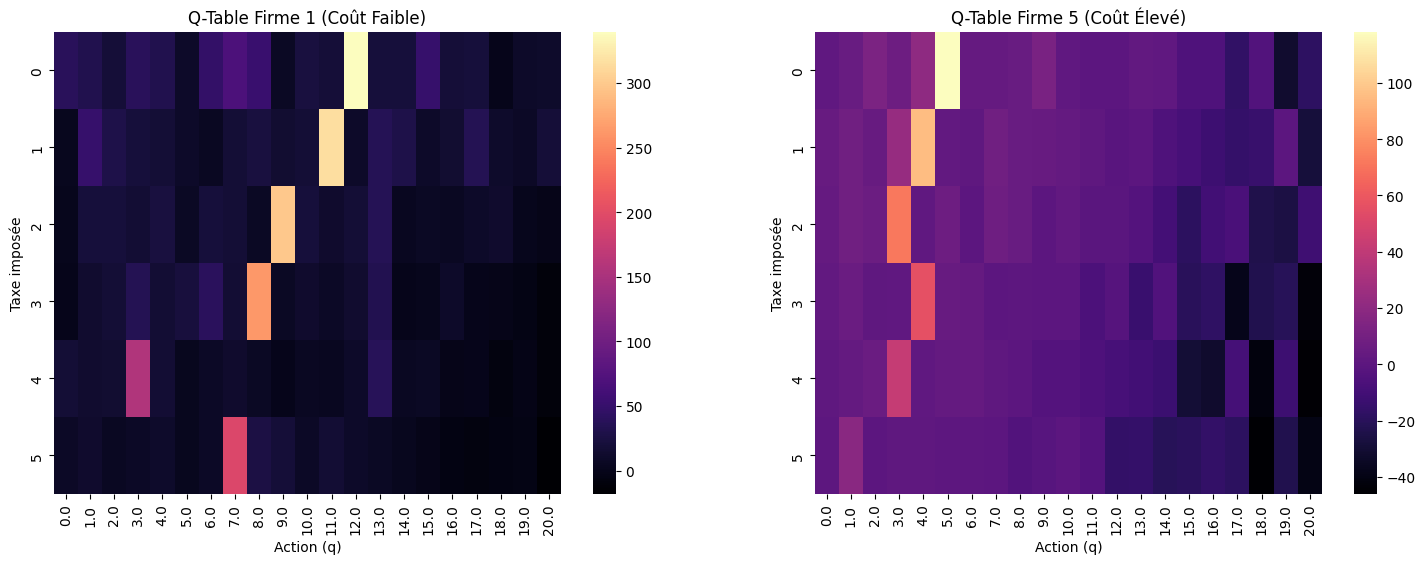

In [36]:
def plot_firm_qtable(firm_agent, title):
    # On filtre les états de type Taxe (0)
    tax_states = [s for s in sorted(firm_agent.q_table.keys()) if s[0] == 0]
    if not tax_states: return
    
    q_matrix = np.array([firm_agent.q_table[s] for s in tax_states])
    sns.heatmap(q_matrix, xticklabels=np.round(firm_agent.actions, 1), 
                yticklabels=[s[1] for s in tax_states], cmap="magma")
    plt.title(title)
    plt.xlabel("Action (q)")
    plt.ylabel("Taxe imposée")

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plot_firm_qtable(firms[0], "Q-Table Firme 1 (Coût Faible)")
plt.subplot(1, 2, 2)
plot_firm_qtable(firms[4], "Q-Table Firme 5 (Coût Élevé)")
plt.show()